In [1]:
import numpy as np
import torch
import torch.nn as nn
from typing import Iterable

from utils import data_loader, onehot
from automatons import PatternMatchingAutomaton, Automaton
from architectures import RecursiveNeuralNetworkFromScratch

In [2]:
patternon = PatternMatchingAutomaton([0, 1, 1, 0])
patternon.tokens

2

In [3]:
def sample_callback(model, epoch, seed=0, end_of_sequence_token=patternon.tokens, **kwargs):
	if epoch % 50:
		return

	sample = [seed]
	while sample[-1] != end_of_sequence_token:
		with torch.no_grad():
			p = model.forward(onehot(sample, patternon.tokens+1))["distribution"][-1]
			print(p)
			token = np.random.choice(range(patternon.tokens+1), p=p.detach().numpy())
			sample.append(token)
	print(sample)


In [4]:
RNN = RecursiveNeuralNetworkFromScratch(tokens = patternon.tokens+1, hidden_size=200) # account for the end of sequence token

In [5]:
train_ds = iter(data_loader(patternon))
history = list(RNN.fit(
	train_ds,
	epochs=300,
	callbacks=[sample_callback],
))

/home/ventus/pattern-learning/utils.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.nn.functional.one_hot(torch.tensor(sequence), num_classes=tokens).float()


tensor([0.3907, 0.5305, 0.0789])
tensor([0.0835, 0.9033, 0.0132])
tensor([0.3697, 0.4886, 0.1417])
tensor([0.7547, 0.1530, 0.0923])
tensor([0.4873, 0.3776, 0.1351])
tensor([0.1446, 0.7301, 0.1253])
tensor([0.3697, 0.4886, 0.1417])
[0, 1, 1, 1, 0, 1, 1, 2]
tensor([0.3710, 0.5946, 0.0344])
tensor([0.6507, 0.2945, 0.0548])
tensor([0.3989, 0.4754, 0.1257])
tensor([0.1946, 0.7039, 0.1014])
tensor([0.4380, 0.4608, 0.1013])
[0, 0, 0, 1, 1, 2]
tensor([0.4235, 0.5508, 0.0257])
tensor([0.5573, 0.4237, 0.0189])
tensor([0.3440, 0.5995, 0.0565])
tensor([0.3167, 0.5067, 0.1767])
tensor([0.5219, 0.3309, 0.1472])
tensor([0.5638, 0.3894, 0.0468])
tensor([0.3440, 0.5995, 0.0565])
tensor([0.3167, 0.5067, 0.1767])
[0, 1, 0, 1, 1, 1, 0, 1, 2]
tensor([0.3530, 0.6240, 0.0231])
tensor([6.2369e-04, 9.9568e-01, 3.6967e-03])
tensor([0.6141, 0.3303, 0.0556])
tensor([9.9667e-01, 6.7559e-04, 2.6509e-03])
tensor([0.3043, 0.5889, 0.1068])
tensor([6.4612e-04, 9.9163e-01, 7.7206e-03])
tensor([0.6141, 0.3303, 0.0556])
t

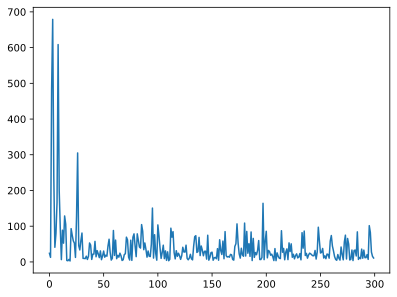

In [6]:
import matplotlib.pyplot as plt

plt.plot(history)
# ?????????????